# Creative Fatigue – Final Submission Notebook
## **Title**: “Predicting Creative Fatigue in Paid Social Advertising Using Machine Learning and Survival Analysis for Performance Marketing Optimization”

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from xgboost import XGBClassifier
from lifelines import KaplanMeierFitter, CoxPHFitter

from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold,
    RandomizedSearchCV,
    GridSearchCV
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

## Introduction

In digital advertising, creative assets such as images and videos tend to lose effectiveness over time due to repeated exposure to the same audience. This phenomenon, commonly referred to as *creative fatigue*, results in declining engagement metrics such as click-through rate (CTR), ultimately impacting campaign performance and return on investment.

Despite its practical importance, creative fatigue is often not formally defined or systematically measured in existing workflows. Most approaches rely on heuristic decisions without a structured, data-driven framework.

This notebook aims to address this gap by developing a data-driven approach to detect and predict creative fatigue using machine learning techniques and survival analysis. The goal is to understand how performance evolves over time and to provide actionable insights for early intervention.

## Problem Statement

Creative performance in digital advertising declines over time due to repeated exposure, but there is no standardized or operational definition of when a creative becomes "fatigued." 

Additionally, existing approaches lack predictive capabilities, making it difficult for marketers to identify fatigue early and take corrective actions. This creates a need for a systematic framework that can both define fatigue and predict its occurrence based on performance trends and exposure patterns.

## Objectives

The main objective of the study is to format a data-driven framework or pipeline for identifying or predicting creative fatigue in paid social advertising. To achieve this, the study aims to:
- Define a rule-based method to label the creative fatigue based on performance decline over time
- Find relevant features which capture the performance patterns and temporal behaviour of advertising creatives
- Evaluate and compare multiple ML models for predicting creative fatigue
- Apply survival analysis techniques to identify the timing and progression of creative fatigue
- Evaluate actionable insights which can support more effective way of campaign optimization strategies 

## Dataset Description

The dataset consists of advertising performance metrics collected over time for multiple creatives. Each record represents the performance of a creative at a given time point.

Key variables include:

- **CTR (Click-Through Rate):** Indicator of engagement and performance
- **Impressions:** Number of times the creative was shown
- **Clicks:** Number of user interactions
- **Time-based features:** Used to capture performance trends over time

The dataset used in this project is the Japanese Instagram Advertising Dataset available on [**Zenodo**](https://zenodo.org/records/18038706).

This dataset was originally developed by Inoue and Yoshida (forthcoming) to study the impact of linguistic features on CTR in Instagram advertisements. It contains anonymized caption texts, product category labels (supplement or cosmetic), impressions, clicks, and computed CTR values used in the analyses. Brand identifiers and sensitive information have been masked to comply with privacy requirements. It is structured as a time series for each creative, enabling the analysis of performance decay and fatigue behavior.

In [2]:
df = pd.read_csv("Instagram_advertising_dataset.csv")

print("Dataset shape:", df.shape)

df.dtypes.value_counts()

df.isnull().sum().sort_values(ascending=False).head(10)

Dataset shape: (21692, 164)


Impressions       0
Clicks            0
CTR               0
CTR_log           0
Caption_masked    0
Start             0
End               0
WC                0
affect            0
posemo            0
dtype: int64

### Dataset Overview

The dataset used in this study is an open-source Instagram advertising dataset, which contains performance data for a large number of advertising creatives. The dataset includes **21,692 observations** and **164 features**, providing a comprehensive view of advertisement performance across time.
The data consists of several types of variables:
- Performance metrics, such as impressions, clicks, and CTR, which capture user engagement 
- Derived features, including log-transformed CTR (CTR_log), used to handle skewness in the data 
- Text-based variables, representing creative captions and linguistic attributes 
- Temporal variables, including start and end dates, which enable time-based analysis 

## Exploratory Data Analysis (EDA)

This section explores the dataset to identify patterns in creative performance over time and to validate the presence of creative fatigue.

### CTR Histogram

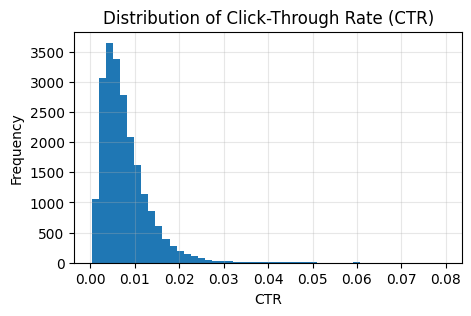

In [3]:
plt.figure(figsize=(5,3))
plt.grid(alpha=0.3)
plt.hist(df["CTR"], bins=50)
plt.xlabel("CTR")
plt.ylabel("Frequency")
plt.title("Distribution of Click-Through Rate (CTR)")
plt.show()

**Insight:** The distribution of CTR is right-skewed, indicating that most creatives achieve relatively low engagement rates, while only a small number of creatives perform exceptionally well. This highlights the importance of monitoring performance over time, as even high-performing creatives may eventually decline, contributing to the phenomenon of creative fatigue.

### CTR Decay Curves

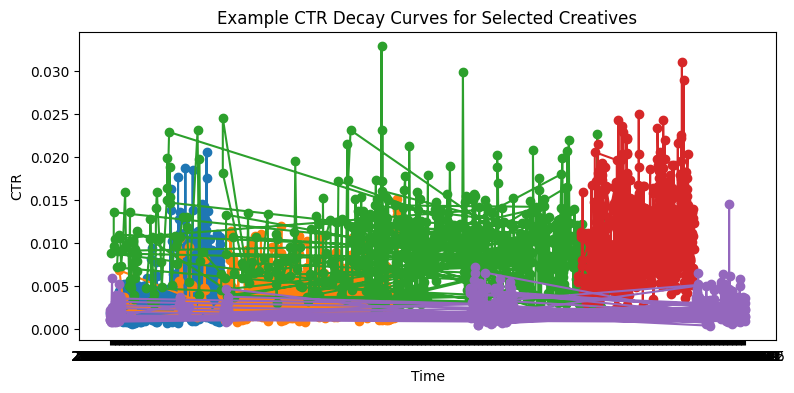

In [4]:
sample_captions = df["Caption_masked"].value_counts().index[:5]

plt.figure(figsize=(9,4))
for cap in sample_captions:
    temp = df[df["Caption_masked"] == cap].sort_values("Start")
    plt.plot(temp["Start"], temp["CTR"], marker="o")

plt.xlabel("Time")
plt.ylabel("CTR")
plt.title("Example CTR Decay Curves for Selected Creatives")
plt.show()

**Insight:** The figure presents CTR trajectories for a sample of ad creatives deployed across multiple campaign periods. Although performance patterns vary across creatives, several exhibit an initial peak followed by a sustained decline in CTR over time. This heterogeneity and post-peak deterioration support the treatment of creative fatigue as a measurable temporal phenomenon rather than a static performance outcome.

## Data Pre-processing
Date variables were converted into datetime format, and campaign duration was calculated in days.

In [5]:
df["Start"] = pd.to_datetime(df["Start"])
df["End"] = pd.to_datetime(df["End"])
df["campaign_days"] = (df["End"] - df["Start"]).dt.days

### CTR vs Campaign Duration

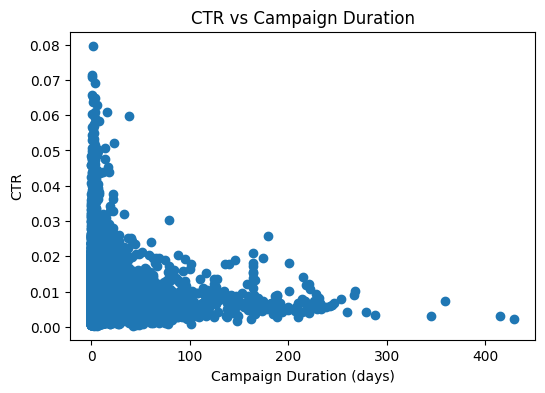

In [6]:
plt.figure(figsize=(6,4))
plt.scatter(df["campaign_days"], df["CTR"])
plt.xlabel("Campaign Duration (days)")
plt.ylabel("CTR")
plt.title("CTR vs Campaign Duration")
plt.show()

**Insight:** The scatter plot illustrates the relationship between campaign duration and CTR. While CTR values vary across campaigns of different lengths, a general tendency towards lower CTR values is observed as campaign duration increases. This suggests that prolonged exposure may be associated with declining performance, motivating further analysis of creative fatigue using temporal decay patterns.

## Fatigue Labelling (Ground Truth Construction)
Creative fatigue is defined as a noticeable decline in advertising performance over time.

To create the fatigue labels, the data is first arranged in chronological order for each creative using the Caption_masked identifier and the Start time. For each creative, the cumulative maximum CTR is calculated to track the best performance achieved up to each point in time. The drop from this peak is then computed to measure how much the current performance has declined.

An observation is labelled as fatigued when two conditions are met: the CTR has dropped by at least 40% compared to the best value observed so far, and the current CTR is decreasing compared to the previous time step. This ensures that fatigue is identified only when there is both a significant decline and a continuing downward trend. The first observation for each creative is always labelled as non-fatigued, since there is no prior data for comparison.

This approach uses only past information at each step and does not rely on future data, ensuring that the labels are realistic and free from data leakage. It also provides a consistent and intuitive way to define creative fatigue for model training.

In [7]:
df_temp = df.copy()
df_temp = df_temp.sort_values(by=["Caption_masked", "Start"]).reset_index(drop=True)
df_temp["fatigued"] = 0

drop_fraction = 0.40

for creative, group in df_temp.groupby("Caption_masked"):
    group = group.sort_values("Start").copy()

    if len(group) < 3:
        continue

    group["CTR_cummax"] = group["CTR"].cummax()

    group["CTR_drop_from_cummax"] = (
        (group["CTR_cummax"] - group["CTR"]) / group["CTR_cummax"]
    )

    group["CTR_change"] = group["CTR"].diff()

    group["CTR_drop_from_cummax"] = group["CTR_drop_from_cummax"].replace([np.inf, -np.inf], 0)
    group["CTR_drop_from_cummax"] = group["CTR_drop_from_cummax"].fillna(0)
    group["CTR_change"] = group["CTR_change"].fillna(0)

    group["fatigued"] = (
        (group["CTR_drop_from_cummax"] >= drop_fraction) &
        (group["CTR_change"] < 0)
    ).astype(int)

    first_idx = group.index[0]
    group.loc[first_idx, "fatigued"] = 0

    df_temp.loc[group.index, "fatigued"] = group["fatigued"]

print(df_temp["fatigued"].value_counts())
print((df_temp["fatigued"].value_counts(normalize=True) * 100).round(2))

fatigued
0    12284
1     9408
Name: count, dtype: int64
fatigued
0    56.63
1    43.37
Name: proportion, dtype: float64


In [8]:
df["fatigued"] = df_temp["fatigued"]

**Labelling Outcome:** The final rule-based labelling approach resulted in a relatively balanced target distribution, with approximately 43% of observations labelled as fatigued and 57% as non-fatigued.

This indicates that the dataset does not suffer from severe class imbalance and is suitable for training supervised machine learning models without requiring heavy resampling techniques.

In addition, different threshold values (20%, 40%, and 50%) were tested to evaluate their impact on the labelling distribution and model behaviour. The 40% threshold was selected as it provided the most balanced and meaningful representation of fatigue, while also avoiding excessive sensitivity (at lower thresholds) or overly strict labelling (at higher thresholds).

Furthermore, the use of both a decline threshold and a negative change condition ensures that fatigue is identified only when there is a meaningful and consistent drop in performance, rather than short-term fluctuations or noise.

## Feature Engineering

To support fatigue prediction, features were engineered to capture performance changes, exposure context, and temporal progression, while avoiding the use of future information.

The dataset was explicitly sorted by creative identifier (`Caption_masked`) and chronological order (`Start`) prior to applying cumulative and sequential operations such as cumulative maximum (cummax) and first-order differences. This step is essential because such operations depend on row order, and improper sorting can lead to incorrect feature values and misleading model behavior.

The feature set is organized into three categories:

- **Performance-based features**, such as CTR and CTR change, which capture short-term variations and performance dynamics  
- **Exposure-based features**, such as impressions and clicks, which provide contextual information about campaign reach  
- **Cumulative temporal features**, such as creative age and drop from cumulative maximum CTR, which represent performance decline over time in a leakage-safe manner  

These features enable the model to learn how creative fatigue evolves over time using only current and past information, ensuring a realistic and robust modeling approach.

In [9]:
df["Start"] = pd.to_datetime(df["Start"])
df["End"] = pd.to_datetime(df["End"])

df = df.sort_values(["Caption_masked", "Start"]).copy()
df = df.fillna(0)

df["creative_age"] = df.groupby("Caption_masked").cumcount() + 1

df["CTR_change"] = df.groupby("Caption_masked")["CTR"].diff()

df["CTR_cummax"] = df.groupby("Caption_masked")["CTR"].cummax()

df["CTR_drop_from_cummax"] = (
    (df["CTR_cummax"] - df["CTR"]) / df["CTR_cummax"]
)

df.head(3)

,Impressions,Clicks,CTR,CTR_log,Caption_masked,Start,End,WC,affect,posemo,...,id0124,id0127,id0128,id0129,campaign_days,fatigued,creative_age,CTR_change,CTR_cummax,CTR_drop_from_cummax
6130,12603,120,0.009522,-4.654198,"""<***>企業が世界中を探して見つけた最高品質の<***>配合🦌\r\n超高保湿で敏感肌ケ...",2021-09-02,2021-09-14,43,4.651163,2.325581,...,0,0,0,0,12,0,1,NaN,0.009522,0.000000
8474,15525,122,0.007858,-4.846186,"""<***>企業が世界中を探して見つけた最高品質の<***>配合🦌\r\n超高保湿で敏感肌ケ...",2021-09-02,2021-09-03,43,4.651163,2.325581,...,0,0,0,0,1,0,2,-0.001663,0.009522,0.174683
18923,19195,56,0.002917,-5.837053,"""<***>企業が世界中を探して見つけた最高品質の<***>配合🦌\r\n超高保湿で敏感肌ケ...",2021-09-02,2021-09-10,43,4.651163,2.325581,...,0,0,0,0,8,1,3,-0.004941,0.009522,0.693597


### Feature Cleaning

Certain engineered features can produce missing values at group boundaries or undefined ratios. These values were replaced with zero to ensure model compatibility and maintain a consistent feature matrix.

In [10]:
df["CTR_change"] = df["CTR_change"].fillna(0)

df["CTR_drop_from_cummax"] = df["CTR_drop_from_cummax"].replace([np.inf, -np.inf], 0)
df["CTR_drop_from_cummax"] = df["CTR_drop_from_cummax"].fillna(0)

df["creative_age"] = df["creative_age"].replace([np.inf, -np.inf], 0)
df["creative_age"] = df["creative_age"].fillna(0)

## Feature Selection

In [11]:
feature_cols = [
    "CTR",
    "CTR_log",
    "Impressions",
    "Clicks",
    "campaign_days",
    "creative_age",
    "CTR_change",
    "CTR_drop_from_cummax"
]

X = df[feature_cols]
y = df["fatigued"]

print(df[feature_cols].isnull().sum())
print(X.shape, y.shape)

CTR                     0
CTR_log                 0
Impressions             0
Clicks                  0
campaign_days           0
creative_age            0
CTR_change              0
CTR_drop_from_cummax    0
dtype: int64
(21692, 8) (21692,)


## Train/Test Split (Group-Aware)
To prevent leakage across creatives, the dataset was split using a group-aware strategy based on `Caption_masked`. This ensures that all observations belonging to the same creative remain entirely within either the training set or the testing set.

This approach is more appropriate than a random row-level split because the dataset contains multiple time-ordered observations per creative. Keeping creatives fully separated avoids training on one part of a creative’s lifecycle while testing on another.

The resulting split also preserved a similar class distribution across both sets while ensuring zero overlap in creatives.

In [12]:
groups = df["Caption_masked"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True).round(4))

print("\nUnique creatives in train:", df.iloc[train_idx]["Caption_masked"].nunique())
print("Unique creatives in test:", df.iloc[test_idx]["Caption_masked"].nunique())

print("Overlap in creatives:",
      len(set(df.iloc[train_idx]["Caption_masked"]) &
          set(df.iloc[test_idx]["Caption_masked"])))

Train shape: (15977, 8) (15977,)
Test shape: (5715, 8) (5715,)

Train label distribution:
fatigued
0    0.5675
1    0.4325
Name: proportion, dtype: float64

Test label distribution:
fatigued
0    0.5629
1    0.4371
Name: proportion, dtype: float64

Unique creatives in train: 606
Unique creatives in test: 152
Overlap in creatives: 0


### Model Training Setup
The dataset was divided into training and testing sets using an 80–20 split with a group-aware strategy based on Caption_masked. This ensured that all observations belonging to the same creative were assigned entirely to either the training set or the testing set, preventing leakage across creative lifecycles. The resulting split preserved a similar class distribution across both sets, with approximately 56–57% non-fatigued and 43–44% fatigued observations.

Given this relatively balanced label distribution, no additional resampling techniques such as SMOTE or ADASYN were applied. Moreover, because the dataset reflects time-dependent advertising performance patterns, synthetic oversampling was avoided to prevent distortion of the natural temporal behavior of the creatives.

## Baseline Model Training

### Logistic Regression

In [13]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced")

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.56      0.64      0.60      3217
           1       0.43      0.35      0.39      2498

    accuracy                           0.52      5715
   macro avg       0.50      0.50      0.49      5715
weighted avg       0.51      0.52      0.51      5715



A Logistic Regression model was implemented as a baseline to assess the predictive capability of the engineered features.

The model achieved an overall accuracy of 52%, with a macro-averaged F1-score of 0.49, indicating limited performance across both classes. The model performed better on the non-fatigued class (F1-score = 0.60) compared to the fatigued class (F1-score = 0.39), suggesting that it struggles to accurately identify fatigue cases.

This imbalance in performance highlights the model’s limitation in capturing the underlying patterns of creative fatigue. Since Logistic Regression is a linear model, it is unable to effectively model the complex, non-linear relationships and temporal dynamics that influence ad performance over time.

Therefore, more advanced models, particularly tree-based methods, are explored in the subsequent section to better capture the complexity of fatigue behavior.

## Random Forest Model

A Random Forest classifier was used to capture non-linear relationships between the engineered features and the fatigue label. This model is well-suited for identifying complex interactions among performance trends, exposure variables, and temporal dynamics.

In [14]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
              precision    recall  f1-score   support

           0       0.59      0.76      0.66      3217
           1       0.50      0.31      0.38      2498

    accuracy                           0.56      5715
   macro avg       0.54      0.54      0.52      5715
weighted avg       0.55      0.56      0.54      5715



A Random Forest classifier was employed to capture non-linear relationships between the engineered features and the fatigue label. This model is well-suited for identifying complex interactions among performance trends, exposure variables, and temporal dynamics.

The Random Forest model achieved an overall accuracy of **56%**, with a macro-averaged F1-score of **0.52**, indicating a moderate improvement over the baseline Logistic Regression model.

Class-wise performance shows that the model performed significantly better on the non-fatigued class (recall = **0.76**, F1-score = **0.66**) compared to the fatigued class (recall = **0.31**, F1-score = **0.38**). This indicates that while the model is effective at identifying non-fatigued creatives, it struggles to accurately detect fatigue instances.

This imbalance suggests that although Random Forest is capable of capturing non-linear relationships and feature interactions, it tends to favor the majority class. As a result, it remains less effective in identifying fatigue cases, which are critical for practical decision-making in advertising performance optimization.

## XGBoost Model

XGBoost (Extreme Gradient Boosting) was implemented as an advanced ensemble model due to its ability to iteratively improve predictions by focusing on previously misclassified instances. It is well-suited for capturing complex, non-linear relationships and interactions within the data.

To account for mild class imbalance, class weighting was incorporated using the `scale_pos_weight` parameter. The model was trained and evaluated using the group-aware train/test split, ensuring that performance reflects generalization to entirely unseen creatives.

In [15]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Results:
              precision    recall  f1-score   support

           0       0.61      0.59      0.60      3217
           1       0.49      0.51      0.50      2498

    accuracy                           0.55      5715
   macro avg       0.55      0.55      0.55      5715
weighted avg       0.56      0.55      0.56      5715



The XGBoost model achieved an overall accuracy of **55%**, with a macro-averaged F1-score of **0.55**, indicating more balanced and consistent performance across both classes compared to previous models.

Class-wise performance shows improved detection of fatigued creatives (recall = **0.51**, F1-score = **0.50**) compared to Random Forest, while maintaining stable performance on the non-fatigued class (F1-score = **0.60**). This suggests that XGBoost is more effective at capturing fatigue-related patterns without heavily biasing toward the majority class.

Overall, the results indicate that XGBoost provides a better balance between precision and recall across both classes. Its ability to model non-linear relationships and sequential performance behavior makes it more suitable for predicting creative fatigue compared to simpler linear and ensemble models.

## XGBoost + RandomizedSearchCV

To further improve model performance, hyperparameter tuning was conducted using RandomizedSearchCV on the XGBoost model. This approach allows efficient exploration of multiple parameter combinations while reducing computational cost compared to exhaustive grid search.

Since the dataset contains time-dependent observations grouped by creatives, a standard cross-validation approach would introduce data leakage by allowing different time steps of the same creative to appear in both training and validation folds. To prevent this, GroupKFold cross-validation was implemented using the creative identifier (`Caption_masked`) as the grouping variable.

This ensures that all observations belonging to a single creative are kept within the same fold, thereby validating the model on entirely unseen creatives and maintaining the integrity of the evaluation process.

In [16]:
groups_train = df.iloc[train_idx]["Caption_masked"]

gkf = GroupKFold(n_splits=5)

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
)

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1_macro',
    cv=gkf.split(X_train, y_train, groups=groups_train), 
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [17]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_tuned = XGBClassifier(
    subsample=0.7,
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_tuned.fit(X_train, y_train)

y_pred_xgb_tuned = xgb_tuned.predict(X_test)

print("Tuned XGBoost Results:")
print(classification_report(y_test, y_pred_xgb_tuned))

Tuned XGBoost Results:
              precision    recall  f1-score   support

           0       0.61      0.57      0.59      3217
           1       0.49      0.53      0.51      2498

    accuracy                           0.55      5715
   macro avg       0.55      0.55      0.55      5715
weighted avg       0.56      0.55      0.55      5715



The tuned XGBoost model achieved an overall accuracy of **55%**, with a macro-averaged F1-score of **0.55**, indicating balanced and consistent performance across both classes.

Class-wise performance shows improved detection of fatigued creatives, with recall increasing to **0.53** and an F1-score of **0.51**. At the same time, the model maintained stable performance on the non-fatigued class (F1-score = **0.59**). This reflects a better balance between precision and recall compared to previous models, particularly in identifying fatigue cases.

Compared to Logistic Regression and Random Forest, the tuned XGBoost model demonstrates superior overall performance and improved capability in capturing fatigue-related patterns. This suggests that gradient boosting methods are more effective in modeling the non-linear and temporal dynamics of creative fatigue.

A further extensive hyperparameter tuning attempt was conducted using a broader search space and increased iterations. However, this did not result in performance improvement, with a slight decrease in macro F1-score observed. This indicates that the model had already reached near-optimal performance and that additional tuning may lead to marginal overfitting rather than improved generalization.

Overall, the tuned XGBoost model was selected as the final model for this study due to its balanced performance, improved fatigue detection, and strong generalization to unseen creatives.

## XGBoost + GridSearchCV

To further validate the robustness of the model optimization process, GridSearchCV was applied to the XGBoost model. Unlike RandomizedSearchCV, GridSearchCV performs an exhaustive search over a predefined parameter grid, allowing systematic evaluation of all parameter combinations.

Given the grouped and time-dependent nature of the dataset, standard cross-validation could introduce data leakage by mixing observations from the same creative across folds. To address this, GroupKFold cross-validation was implemented using the creative identifier (`Caption_masked`) as the grouping variable.

This ensures that all observations belonging to a single creative remain within the same fold, thereby preserving the temporal and structural integrity of the data during model validation.

In [18]:
groups_train = df.iloc[train_idx]["Caption_masked"]

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [4, 5, 6],
    "learning_rate": [0.03, 0.05, 0.07],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "gamma": [0, 0.1],
    "min_child_weight": [3, 5]
}

gkf = GroupKFold(n_splits=3)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=gkf.split(X_train, y_train, groups=groups_train),
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_xgb_grid = grid_search.best_estimator_
y_pred_grid = best_xgb_grid.predict(X_test)

print("Best Parameters:", grid_search.best_params_)
print("GridSearchCV Tuned XGBoost Results:")
print(classification_report(y_test, y_pred_grid))

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Parameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 300, 'subsample': 0.8}
GridSearchCV Tuned XGBoost Results:
              precision    recall  f1-score   support

           0       0.61      0.58      0.59      3217
           1       0.49      0.52      0.50      2498

    accuracy                           0.55      5715
   macro avg       0.55      0.55      0.55      5715
weighted avg       0.56      0.55      0.55      5715



GridSearchCV was applied to systematically explore the hyperparameter space of the XGBoost model. The optimized model achieved an overall accuracy of **55%**, with a macro-averaged F1-score of **0.55**, consistent with the results obtained from RandomizedSearchCV.

Class-wise performance shows comparable results, with an F1-score of **0.50** and recall of **0.52** for the fatigued class. This indicates that the model maintains a balanced performance across both classes.

The similarity in performance between GridSearchCV and RandomizedSearchCV suggests that the model has reached a stable and near-optimal configuration. Further tuning did not yield significant improvements, reinforcing that performance is constrained more by the feature representation and data characteristics than by hyperparameter selection.

These results provide additional validation of the robustness and reliability of the final XGBoost model.

## Model Comparison

In [19]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost (Baseline)",
        "XGBoost + RandomizedSearchCV",
        "XGBoost + GridSearchCV"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_xgb_tuned),
        accuracy_score(y_test, y_pred_grid)
    ],
    "F1 (Macro)": [
        f1_score(y_test, y_pred_lr, average="macro"),
        f1_score(y_test, y_pred_rf, average="macro"),
        f1_score(y_test, y_pred_xgb, average="macro"),
        f1_score(y_test, y_pred_xgb_tuned, average="macro"),
        f1_score(y_test, y_pred_grid, average="macro")
    ],
    "F1 (Fatigue)": [
        f1_score(y_test, y_pred_lr, pos_label=1),
        f1_score(y_test, y_pred_rf, pos_label=1),
        f1_score(y_test, y_pred_xgb, pos_label=1),
        f1_score(y_test, y_pred_xgb_tuned, pos_label=1),
        f1_score(y_test, y_pred_grid, pos_label=1)
    ],
    "Recall (Fatigue)": [
        recall_score(y_test, y_pred_lr, pos_label=1),
        recall_score(y_test, y_pred_rf, pos_label=1),
        recall_score(y_test, y_pred_xgb, pos_label=1),
        recall_score(y_test, y_pred_xgb_tuned, pos_label=1),
        recall_score(y_test, y_pred_grid, pos_label=1)
    ]
}).round(2)

In [20]:
model_results

,Model,Accuracy,F1 (Macro),F1 (Fatigue),Recall (Fatigue)
0,Logistic Regression,0.52,0.49,0.39,0.35
1,Random Forest,0.56,0.52,0.38,0.31
2,XGBoost (Baseline),0.55,0.55,0.50,0.51
3,XGBoost + RandomizedSearchCV,0.55,0.55,0.51,0.53
4,XGBoost + GridSearchCV,0.55,0.55,0.50,0.52


A comparative evaluation of all models was conducted using accuracy, macro-averaged F1-score, and fatigue-specific metrics. Logistic Regression demonstrated the weakest performance, confirming that linear models are insufficient for capturing the complexity of creative fatigue.

Random Forest showed moderate improvement in overall accuracy but exhibited a bias toward the non-fatigued class, resulting in weaker fatigue detection performance, as reflected by its lower recall for the fatigued class.

XGBoost significantly improved performance by providing a better balance between classes. The baseline XGBoost model matched the highest macro F1-score (0.55), while the GridSearchCV-tuned model achieved slightly higher recall for the fatigued class (0.52), with both models showing nearly identical overall performance.

In contrast, RandomizedSearchCV provided a slight improvement in fatigue detection performance, achieving the highest recall (0.53) and fatigue-specific F1-score (0.51), although the overall performance remained very similar to the baseline and GridSearchCV models.

The similarity in performance across all XGBoost variants indicates that the model has reached a stable and near-optimal configuration. This suggests that further improvements are more likely to come from enhanced feature representation rather than increased model complexity.

Overall, XGBoost was selected as the final modelling approach due to its balanced performance, improved fatigue detection capability, and robustness across different validation strategies. These results also highlight an important trade-off between overall model balance and fatigue detection sensitivity, which is critical in real-world marketing applications.

In [21]:
model_results.style.highlight_max(axis=0, subset=[
    "Accuracy",
    "F1 (Macro)",
    "F1 (Fatigue)",
    "Recall (Fatigue)"
])

,Model,Accuracy,F1 (Macro),F1 (Fatigue),Recall (Fatigue)
0,Logistic Regression,0.520000,0.490000,0.390000,0.350000
1,Random Forest,0.560000,0.520000,0.380000,0.310000
2,XGBoost (Baseline),0.550000,0.550000,0.500000,0.510000
3,XGBoost + RandomizedSearchCV,0.550000,0.550000,0.510000,0.530000
4,XGBoost + GridSearchCV,0.550000,0.550000,0.500000,0.520000


A comparative evaluation of all models was conducted using accuracy, macro-averaged F1-score, and fatigue-specific metrics. Logistic Regression demonstrated the weakest performance, confirming that linear models are insufficient for capturing the complexity of creative fatigue.

Random Forest showed moderate improvement in overall accuracy but exhibited a bias toward the non-fatigued class, resulting in weaker fatigue detection performance, as reflected by its lower recall for the fatigued class.

XGBoost significantly improved performance by providing a better balance between classes. The baseline XGBoost model achieved the highest macro F1-score (0.55), while the GridSearchCV-tuned model achieved slightly higher recall for the fatigued class (0.52), with both models showing nearly identical overall performance.

In contrast, RandomizedSearchCV provided a slight improvement in fatigue detection performance, achieving the highest recall (0.53) and fatigue-specific F1-score (0.51), although the overall performance remained very similar to the baseline and GridSearchCV models.

The similarity in performance across all XGBoost variants indicates that the model has reached a stable and near-optimal configuration. This suggests that further improvements are more likely to come from enhanced feature representation rather than increased model complexity.

Overall, XGBoost was selected as the final modelling approach due to its balanced performance, improved fatigue detection capability, and robustness across different validation strategies. These results also highlight an important trade-off between overall model balance and fatigue detection sensitivity, which is critical in real-world marketing applications.

## Feature Importances

                Feature  Importance
1               CTR_log    0.191687
0                   CTR    0.165581
7  CTR_drop_from_cummax    0.112330
3                Clicks    0.111249
6            CTR_change    0.108312
5          creative_age    0.105478
2           Impressions    0.102839
4         campaign_days    0.102525


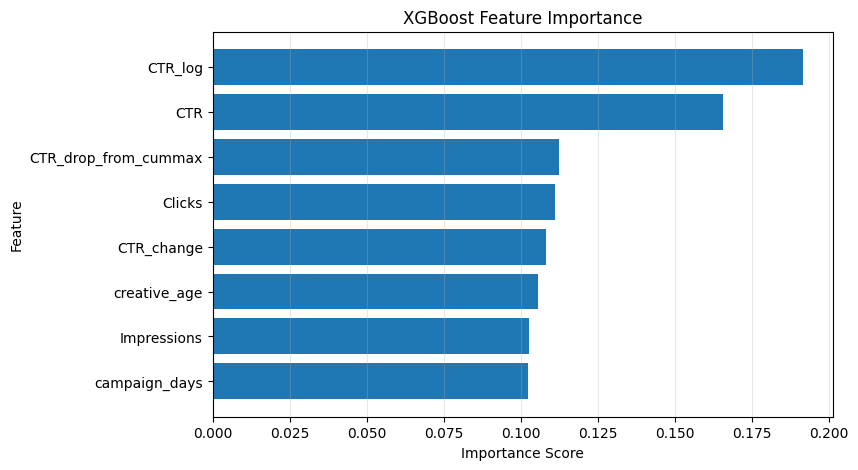

In [22]:
final_model = best_xgb_grid

feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": final_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()

### Research Findings

The feature importance analysis highlights that performance-based features are the most influential predictors of creative fatigue.

Among all features, **CTR_log** and **CTR** emerged as the most important, indicating that the overall engagement level of an advertisement is a primary determinant of fatigue. This suggests that creatives with declining engagement signals are more likely to exhibit fatigue.

The feature **CTR_drop_from_cummax** also shows high importance, confirming that the relative decline from a creative’s peak performance is a strong indicator of fatigue. This aligns directly with the labeling logic, reinforcing the validity of the fatigue definition used in this study.

Additionally, **CTR_change** contributes significantly, capturing short-term performance fluctuations and immediate drops in effectiveness. This indicates that both gradual decline and short-term deterioration play a role in fatigue detection.

Temporal features such as **creative_age** and **campaign_days** also demonstrate meaningful importance, suggesting that fatigue is a progressive phenomenon that develops over time rather than occurring abruptly.

In contrast, exposure-based features such as **impressions** and **clicks** have relatively lower importance. This indicates that creative fatigue is not solely driven by audience exposure, but rather by the interaction between performance decline and temporal progression.

Overall, the results suggest that creative fatigue can be effectively characterized as a dynamic process driven by declining engagement over time. The combined influence of performance decay and temporal evolution provides a strong predictive signal for identifying fatigue in advertising creatives.

## Explainability (SHAP)

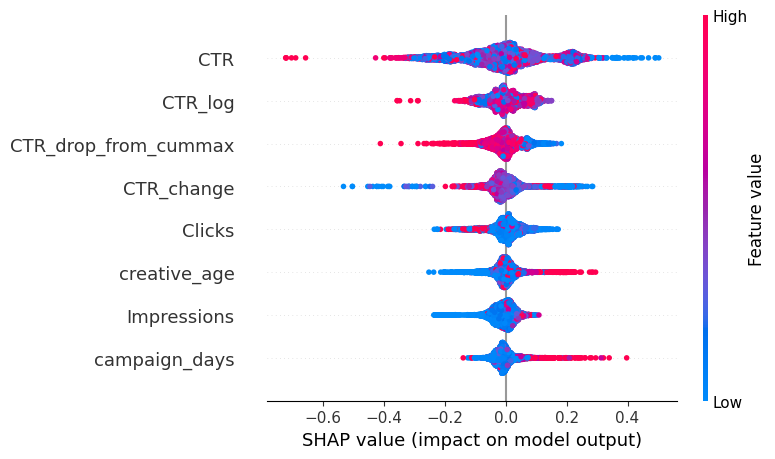

In [23]:
final_model = best_xgb_grid

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

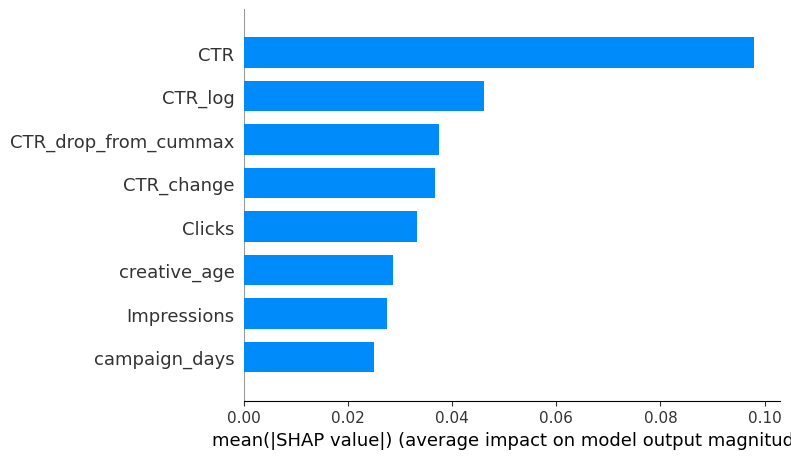

In [24]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

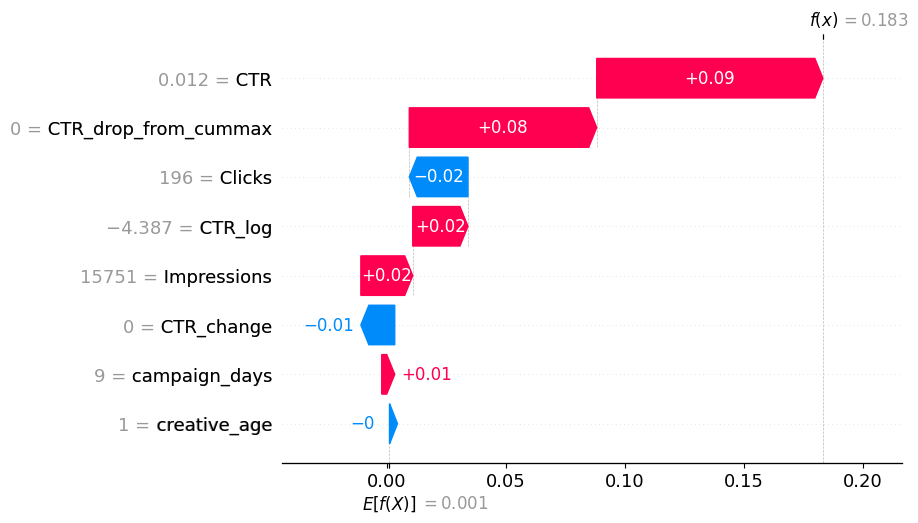

In [25]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

To further interpret the model’s predictions, SHAP (SHapley Additive exPlanations) analysis was conducted on the final XGBoost model. This method provides a detailed understanding of how each feature contributes to individual predictions and overall model behavior.

The SHAP summary plots confirm that **CTR** and **CTR_log** are the most influential features, indicating that the overall engagement level of a creative plays a dominant role in fatigue prediction.

Features related to performance decline, such as **CTR_drop_from_cummax** and **CTR_change**, also show strong contributions, reinforcing that both long-term degradation and short-term fluctuations are key signals of creative fatigue.

Additionally, **creative_age** emerges as an important factor, suggesting that fatigue develops progressively over time as creatives continue to run.

In contrast, exposure-related features such as **impressions** and **clicks** exhibit comparatively lower impact, indicating that fatigue is not solely driven by audience reach but by declining effectiveness over time.

Overall, the SHAP analysis validates the findings from the feature importance analysis and provides further evidence that creative fatigue is a dynamic process driven by the interaction of engagement levels, performance decline, and temporal progression.

## Survival Analysis

In [26]:
survival_data = []

for creative, group in df.groupby("Caption_masked"):
    group = group.sort_values("Start")

    fatigue_rows = group[group["fatigued"] == 1]

    if len(fatigue_rows) > 0:
        first_fatigue = fatigue_rows.iloc[0]
        time = first_fatigue["creative_age"]
        event = 1
    else:
        last_row = group.iloc[-1]
        time = last_row["creative_age"]
        event = 0

    survival_data.append({
        "Caption_masked": creative,
        "time": time,
        "event": event
    })

survival_data = pd.DataFrame(survival_data)

print(survival_data.head())
print(survival_data["event"].value_counts())

                                      Caption_masked  time  event
0  "<***>企業が世界中を探して見つけた最高品質の<***>配合🦌\r\n超高保湿で敏感肌ケ...     3      1
1  "<***>開発【必要な栄養素を効率的に摂れる】完全<***>！\r\n医師監修のWEBアン...     2      1
2  "「頑固な悩みがスッキリ…！」２つの力が掃除機のように内側からスッキリをサポート！\r\n新...     1      0
3  "【定期ではございません】<***>企業が世界中を探して見つけた高品質の<***>配合🦌\r...     1      1
4  11月30日まで！目元美容液パウチ、美白美容液パウチも付いてくる！\r\n「買って正解！」お...     2      1
event
1    619
0    139
Name: count, dtype: int64


In [27]:
feature_df = (
    df.groupby("Caption_masked", as_index=False)
      .agg({
          "CTR": "last",
          "CTR_drop_from_cummax": "max",
          "creative_age": "max"
      })
)

surv_df = (
    survival_data
    .merge(feature_df, on="Caption_masked", how="left")
    [["Caption_masked", "time", "event", "CTR", "CTR_drop_from_cummax", "creative_age"]]
    .dropna()
    .copy()
)

print(surv_df.head())
print(surv_df.shape)

                                      Caption_masked  time  event       CTR  \
0  "<***>企業が世界中を探して見つけた最高品質の<***>配合🦌\r\n超高保湿で敏感肌ケ...     3      1  0.009126   
1  "<***>開発【必要な栄養素を効率的に摂れる】完全<***>！\r\n医師監修のWEBアン...     2      1  0.002842   
2  "「頑固な悩みがスッキリ…！」２つの力が掃除機のように内側からスッキリをサポート！\r\n新...     1      0  0.012444   
3  "【定期ではございません】<***>企業が世界中を探して見つけた高品質の<***>配合🦌\r...     1      1  0.019388   
4  11月30日まで！目元美容液パウチ、美白美容液パウチも付いてくる！\r\n「買って正解！」お...     2      1  0.002583   

   CTR_drop_from_cummax  creative_age  
0              0.693597             4  
1              0.561512            10  
2              0.000000             1  
3              0.652052            20  
4              0.636278            20  
(758, 6)


### Kaplan-Meier Survival Curve

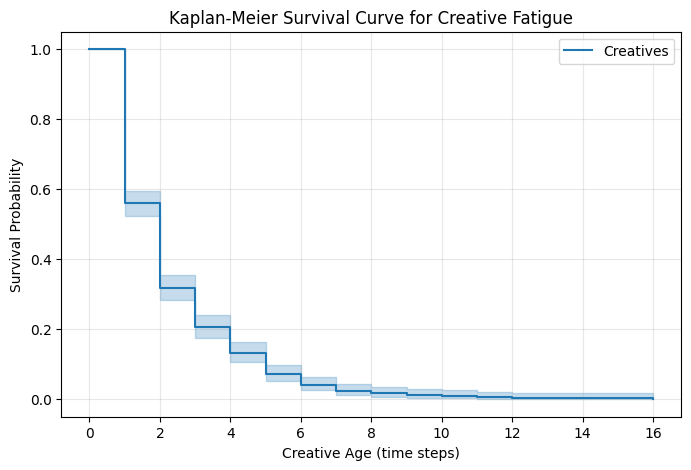

In [28]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(8, 5))
kmf.fit(durations=surv_df["time"], event_observed=surv_df["event"], label="Creatives")
kmf.plot_survival_function()

plt.title("Kaplan-Meier Survival Curve for Creative Fatigue")
plt.xlabel("Creative Age (time steps)")
plt.ylabel("Survival Probability")
plt.grid(alpha=0.3)
plt.show()

**Time to Creative Fatigue:**

The Kaplan–Meier survival curve illustrates the probability that a creative remains non-fatigued over time.

The curve shows a sharp decline in the early stages, indicating that a large proportion of creatives experience fatigue shortly after deployment. The estimated median survival time is approximately **2 time units**, meaning that half of the creatives reach fatigue within a very short period after launch.

As time progresses, the rate of decline slows down, suggesting that creatives which remain effective beyond the initial phase are less likely to fatigue rapidly. This indicates a selection effect, where only stronger-performing creatives continue to survive over time.

Overall, the results confirm that creative fatigue is primarily an early-stage phenomenon, where performance deterioration occurs soon after a creative is introduced. Therefore, monitoring creatives closely during the initial campaign period is critical for timely optimization and creative refresh decisions.

### CTR Comparison by Fatigue Event

event
0    0.009304
1    0.007760
Name: CTR, dtype: float64


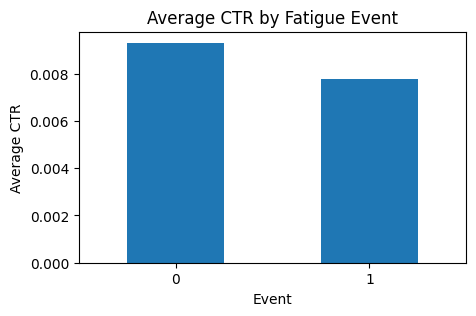

In [29]:
ctr_compare = surv_df.groupby("event")["CTR"].mean()
print(ctr_compare)

ctr_compare.plot(kind="bar", figsize=(5, 3))
plt.title("Average CTR by Fatigue Event")
plt.xlabel("Event")
plt.ylabel("Average CTR")
plt.xticks(rotation=0)
plt.show()

The comparison of average CTR between fatigued and non-fatigued creatives shows that non-fatigued creatives (event = 0) have a slightly higher average CTR (≈ **0.0093**) compared to fatigued creatives (event = 1) with an average CTR of ≈ **0.0078**.

However, the difference between the two groups is relatively small, indicating that absolute CTR alone is not a strong indicator of creative fatigue. Instead, fatigue is better characterized by changes in performance over time rather than static engagement levels.

This finding is consistent with the broader analysis, where dynamic features such as CTR decline and temporal progression were found to be more influential than absolute performance metrics in predicting fatigue.

### Cox Proportional Hazards Model

In [30]:
refined_rows = []

for creative, group in df.groupby("Caption_masked"):
    group = group.sort_values("Start").copy()

    fatigue_rows = group[group["fatigued"] == 1]

    if len(fatigue_rows) > 0:
        first_idx = fatigue_rows.index[0]
        observed_group = group.loc[:first_idx]
        time = group.loc[first_idx, "creative_age"]
        event = 1
    else:
        observed_group = group
        last_row = group.iloc[-1]
        time = last_row["creative_age"]
        event = 0

    refined_rows.append({
        "Caption_masked": creative,
        "time": time,
        "event": event,
        "CTR_drop_from_cummax": observed_group["CTR_drop_from_cummax"].max(),
        "creative_age": observed_group["creative_age"].max()
    })

surv_df = pd.DataFrame(refined_rows)

cox_df = surv_df[["time", "event", "CTR_drop_from_cummax", "creative_age"]].copy()

In [31]:
scaler = StandardScaler()
cox_df[["CTR_drop_from_cummax", "creative_age"]] = scaler.fit_transform(
    cox_df[["CTR_drop_from_cummax", "creative_age"]]
)

cox = CoxPHFitter()
cox.fit(cox_df, duration_col="time", event_col="event")

cox.print_summary()
print("Concordance Index:", round(cox.concordance_index_, 4))

<lifelines.CoxPHFitter: fitted with 758 total observations, 139 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 758
number of events observed = 619
   partial log-likelihood = -2889.77
         time fit was run = 2026-03-26 13:53:12 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
CTR_drop_from_cummax  0.04      1.04      0.07           -0.09            0.17                0.91                1.18
creative_age         -9.40      0.00      1.17          -11.69           -7.11                0.00                0.00

                      cmp to     z      p  -log2(p)
covariate                                          
CTR_drop_from_cummax    0.00  0.54   0.59      0.77
creative_age            0.00 -8.03 <0.005     49.85
---
Concordance = 0.90
Partial AIC = 5783.55
log-likelihood ratio test = 1234.00 on 2 df
-log2(p) of ll-ratio test = 890.14

Concordance Index: 0.9027


A Cox Proportional Hazards model was applied to examine the relationship between key features and the risk of creative fatigue over time. To ensure methodological validity, all covariates were computed only up to the observed event or censoring point, thereby eliminating any potential data leakage from future observations.

The results indicate that creative_age is a statistically significant predictor of fatigue risk (p < 0.005), with a strong negative coefficient. This suggests that the likelihood of a creative remaining effective decreases over time, confirming that creative fatigue is primarily driven by temporal dynamics. In contrast, CTR_drop_from_cummax was not found to be statistically significant (p > 0.05), indicating that short-term performance decline alone may not reliably explain the timing of fatigue within the survival modeling framework.

The model achieved a high concordance index of approximately 0.90, indicating strong predictive ability in ranking creatives based on their risk of fatigue. This demonstrates that the model effectively captures the temporal ordering of fatigue events.

Overall, the findings suggest that while performance-based features contribute to fatigue detection in classification models, time-related dynamics play a more dominant role in explaining when fatigue occurs. The survival analysis complements the machine learning results by providing a time-to-event perspective, reinforcing the conclusion that creative fatigue is a dynamic process that evolves over the lifecycle of an advertisement

## Conclusion

This study aimed to model and predict creative fatigue in social media advertising using performance-based and temporal features. The findings demonstrate that creative fatigue is a dynamic and time-dependent phenomenon, driven primarily by declining performance over time rather than static engagement levels or exposure alone.

The analysis began with a rule-based labelling approach, which was carefully designed to reflect real-world conditions by avoiding future information and incorporating cumulative performance behavior. This resulted in a balanced and meaningful target variable suitable for supervised learning.

Multiple machine learning models were evaluated, including Logistic Regression, Random Forest, and XGBoost. The results showed that linear models were insufficient to capture the complexity of fatigue dynamics, while tree-based models provided improved and more balanced performance. Among all models, XGBoost consistently delivered the strongest results, demonstrating stable performance across different tuning strategies and highlighting the importance of non-linear modeling approaches for this problem.

Feature importance and SHAP analysis revealed that performance-based features, particularly CTR, performance decline from cumulative peak, and short-term changes in CTR, are the most influential predictors of fatigue. Temporal features such as creative age also contributed, indicating that fatigue develops progressively over time. In contrast, exposure-related variables such as impressions and clicks were found to have relatively limited influence.

Survival analysis further reinforced these findings by showing that creative fatigue tends to occur early in the campaign lifecycle, with a rapid decline in survival probability during the initial stages. The Cox Proportional Hazards model identified creative age as a statistically significant predictor of fatigue risk, confirming that the likelihood of fatigue increases over time. The model also achieved a high concordance index, indicating strong predictive capability in ranking creatives based on their risk of fatigue. However, performance decline features were not statistically significant in the survival framework, suggesting that while they are useful for detecting fatigue, they may be less effective in explaining the precise timing of fatigue events.

Overall, the study concludes that creative fatigue is best understood as a dynamic process of performance decay over time, influenced by both short-term fluctuations and long-term decline. These insights provide practical value for marketers, enabling earlier detection of fatigue and more effective timing of creative refresh strategies in digital advertising campaigns.

## Reference:

Inoue, K. and Yoshida, M. (2025) [*Zenodo*](https://zenodo.org/records/18038706) Instagram Advertising Dataset. Available at: https://doi.org/10.5281/zenodo.18038706 (Accessed: 22 January 2026).

Pandas (n.d.) Pandas Documentation. Available at: https://pandas.pydata.org/ (Accessed: 22 January 2026).

NumPy (n.d.) NumPy Documentation. Available at: https://numpy.org/ (Accessed: 22 January 2026).

Matplotlib (n.d.) Matplotlib Documentation. Available at: https://matplotlib.org/ (Accessed: 22 January 2026).

Scikit-learn (n.d.) Scikit-learn Documentation. Available at: https://scikit-learn.org/ (Accessed: 26 February 2026).

XGBoost (n.d.) XGBoost Documentation. Available at: https://xgboost.readthedocs.io/ (Accessed: 26 February 2026).

SHAP (n.d.) SHAP Documentation. Available at: https://shap.readthedocs.io/ (Accessed: 26 February 2026).